<a href="https://colab.research.google.com/github/lilianabs/learning-pytorch/blob/main/Pytorch_basic_example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
np.random.seed(0)
df = pd.DataFrame({
    "feature1": np.random.randn(1000),
    "feature2": np.random.randn(1000),
    "feature3": np.random.randn(1000),
    "target":   np.random.randint(0, 2, size=1000),  # binary classification
})

In [3]:
df.head()

,feature1,feature2,feature3,target
0,1.764052,0.555963,-1.532921,1
1,0.400157,0.892474,-1.711970,1
2,0.978738,-0.422315,0.046135,1
3,2.240893,0.104714,-0.958374,1
4,1.867558,0.228053,-0.080812,0


In [4]:
# Custome dataset
class DataFrameDataset(Dataset):
  def __init__(self, df, feature_cols, target_col):
    self.X = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    self.y = torch.tensor(df[target_col].values, dtype=torch.long)

  def __len__(self):
    return len(self.y)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]


In [5]:
feature_cols = ["feature1", "feature2", "feature3"]
dataset = DataFrameDataset(df, feature_cols, "target")

In [6]:
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])

In [27]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)

In [7]:
from torch.nn.modules.activation import ReLU
# Model
class SimpleNet(nn.Module):
  def __init__(self, in_features, n_classes):
    super().__init__()
    self.net = nn.Sequential(
        nn.Linear(in_features, 32),
        nn.ReLU(),
        nn.Linear(32, 16),
        nn.ReLU(),
        nn.Linear(16, n_classes),
    )

  def forward(self, x):
    return self.net(x)

In [24]:
in_features = len(feature_cols)
n_classes = df["target"].nunique()

In [25]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleNet(in_features=in_features, n_classes=n_classes)

In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [29]:
model.to(device)
criterion.to(device)

# Training loop
n_epochs = 10
for epoch in range(n_epochs):
  model.train()
  train_loss = 0.0
  for X_batch, y_batch in train_loader:
    X_batch, y_batch = X_batch.to(device), y_batch.to(device)

    optimizer.zero_grad()
    logits = model(X_batch)
    loss = criterion(logits, y_batch)
    loss.backward()
    optimizer.step()

    train_loss += loss.item() * X_batch.size(0)
  train_loss /= len(train_ds)

In [30]:
# -- validate --
model.eval()
val_loss, correct = 0.0, 0
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        val_loss += criterion(logits, y_batch).item() * X_batch.size(0)
        correct += (logits.argmax(1) == y_batch).sum().item()
val_loss /= len(val_ds)
val_acc = correct / len(val_ds)

print(f"Epoch {epoch+1:2d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.3f}")

Epoch 10 | train_loss=0.6865 | val_loss=0.6948 | val_acc=0.505


In [21]:
!pip install torchview

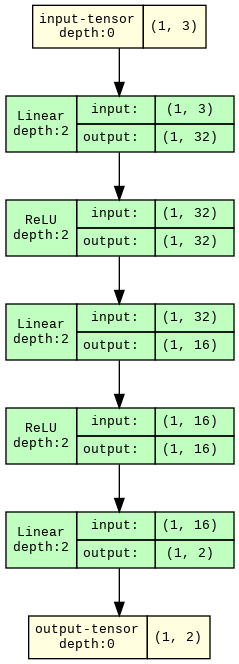

In [22]:
import torchview

# Create a dummy input tensor for tracing
dummy_input = torch.zeros([1, in_features]).to(device)

# Visualize the model using torchview
# We'll save the graph as a PNG image
model_graph = torchview.draw_graph(model, input_size=(1, in_features),
                                   graph_name='SimpleNet_Architecture',
                                   save_graph=True,
                                   directory='.',
                                   filename='simple_net_torchview',
                                   device=device.type)

# To display it directly in Colab:
from IPython.display import Image
Image(filename='simple_net_torchview.png')